<a href="https://colab.research.google.com/github/juliazelena/Data-Visualization-with-Matplotlib/blob/main/sales_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/My Drive/Mate academy

Mounted at /content/drive
/content/drive/My Drive/Mate academy


In [ ]:
#Preview events data
events = pd.read_csv("events.csv")
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
print(events.shape)
events.info()

(1330, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


1. **Order ID** (int64) — унікальний ідентифікатор замовлення.
2. **Order Date** (object) — дата створення замовлення.
3. **Ship Date** (object) — дата відправлення замовлення клієнту.
4. **Order Priority** (object) — пріоритет виконання замовлення.
5. **Country Code** (object, є пропуски) — код країни, з якої здійснено замовлення.
6. **Product ID** (int64) — унікальний ідентифікатор товару.
7. **Sales Channel**(object) — канал продажу (онлайн чи офлайн).
8. **Units Sold** (float64, є пропуски) — кількість одиниць товару, проданих у межах замовлення.
9. **Unit Price**(float64) — ціна за одиницю товару.
10. **Unit Cost** (float64) — собівартість одиниці товару.

Стовпці Order Date та Ship Date мають неправильний тип даних

In [ ]:
#Preview products data
products = pd.read_csv("products.csv")
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
print(products.shape)
products.info()

(12, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


1. **id** (int64) — унікальний ідентифікатор запису
2. **item_type** (object) — категорія товару

In [ ]:
#Preview countries data
countries = pd.read_csv("countries.csv")
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
print(countries.shape)
countries.info()

(249, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


1. **name** (object) — назва країни.
2. **alpha-2** (object, є пропуски) — двосимвольний код країни.
3. **alpha-3** (object) — трисимвольний код країни.
4. **region** (object, є пропуски) — регіон, до якого належить країна.
5. **sub-region** (object, є пропуски) — підрегіон країни.

У датасеті Events є стовпець Product Id, а у Products відповідний стовпець ID. За допомогою цього стовпця можна об’єднати обидва датасети.

У датасеті Events є стовпець Country Code, а у Countries відповідний стовпець alpha-3. За допомогою цього стовпця також можна об’єднати ці датасети.

In [ ]:
# calculate % of missing values
missing_percent = events.isna().sum() * 100 / len(events)

print(missing_percent.round(2))

Order ID          0.00
Order Date        0.00
Ship Date         0.00
Order Priority    0.00
Country Code      6.17
Product ID        0.00
Sales Channel     0.00
Units Sold        0.15
Unit Price        0.00
Unit Cost         0.00
dtype: float64


Oскільки частка пропущених значень **Country Code** становить 6% та може впливати на подальший аналіз встановлюємо для всіх пропущених значень - Unknown.  
У стовпці **Units Sold** пропущено всього три значення, але замінимо ці значення на моду(значення, яке зустрічається найчастіше) для кожної категорії товарів окремо.  
У датасеті по одному пропуску у трьох різних стовпцях їх видалимо.

In [ ]:
#Filling missing data

events['Country Code'] = events['Country Code'].fillna("Unknown")
events["Units Sold"] = events.groupby('Product ID')['Units Sold'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0))
countries = countries.dropna()

In [ ]:
#Changing the data type for Order Date and Ship Date
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])
print(events.dtypes)

Order ID                   int64
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Order Priority            object
Country Code              object
Product ID                 int64
Sales Channel             object
Units Sold               float64
Unit Price               float64
Unit Cost                float64
dtype: object


In [ ]:
#Check and remove duplicates/extra spaces
duplicates_ev = events.duplicated()
print("Кількість дублікатів у таблиці events:", duplicates_ev.sum())
text_cols = events.select_dtypes(include="object").columns
events[text_cols] = events[text_cols].apply(lambda x: x.str.strip())

duplicates_pr = products.duplicated()
print("Кількість дублікатів у таблиці products:", duplicates_pr.sum())
text_cols = products.select_dtypes(include="object").columns
products[text_cols] = products[text_cols].apply(lambda x: x.str.strip())

duplicates_countries = countries.duplicated()
print("Кількість дублікатів у таблиці countries:", duplicates_countries.sum())
text_cols = countries.select_dtypes(include="object").columns
countries[text_cols] = countries[text_cols].apply(lambda x: x.str.strip())

Кількість дублікатів у таблиці events: 0
Кількість дублікатів у таблиці products: 0
Кількість дублікатів у таблиці countries: 0


In [ ]:
#Anomaly detection
events[["Units Sold", "Unit Price", "Unit Cost"]].describe()

,Units Sold,Unit Price,Unit Cost
count,1330.000000,1330.000000,1330.000000
mean,4954.034586,264.893541,187.246812
std,2905.410332,217.323460,176.158873
min,2.000000,9.330000,6.920000
25%,2360.750000,81.730000,35.840000
50%,4962.000000,154.060000,97.440000
75%,7460.500000,437.200000,263.330000
max,9999.000000,668.270000,524.960000


В **Unit Price** та **Unit Cost** середнє значення більше за медіану, що означає що існують великі значення, які збільшують середнє, що дає хибну оцінку.

In [ ]:
#IQR (Interquartile Range) method for outlier detection

def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

columns_to_check = ["Units Sold", "Unit Price", "Unit Cost"]

outliers_dict = {}
for col in columns_to_check:
    outliers_dict[col] = find_outliers_iqr(events, col)
    print(f"Outliers in {col}: {len(outliers_dict[col])} rows")


Outliers in Units Sold: 0 rows
Outliers in Unit Price: 0 rows
Outliers in Unit Cost: 0 rows


За допомогою методу міжквартильного розмаху, перевірили що аномальних значень в стовпцях немає.

In [ ]:
#inner join events and products on "Product ID"
events_and_products_join = pd.merge(events, products, left_on="Product ID", right_on="id", how="inner")
events_and_products_join = events_and_products_join.drop(columns="id")
events_and_products_join.rename(columns={"item_type": "Product Category", "Unit Cost": "Cost"}, inplace=True)
print(events_and_products_join)


       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
2     101025998 2014-07-18 2014-08-11              M      Unknown        7940   
3     102230632 2017-05-13 2017-06-13              L          MNE        2455   
4     103435266 2012-08-11 2012-09-18              H          SRB        1270   
...         ...        ...        ...            ...          ...         ...   
1325  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1326  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1327  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1328  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1329  999879729 2012-03-31 2012-05-06              M          ALB        7940   

     Sales Channel  Units S

In [ ]:
#inner join events and contries on "Country Code"
data = pd.merge(events_and_products_join, countries, left_on="Country Code", right_on="alpha-3", how="inner")
data = data.drop(columns=["alpha-3", "alpha-2"])
data.rename(columns={"name": "Country"}, inplace=True)
data["Revenue"] = (data['Unit Price'] * data['Units Sold'])
data["Profit"] = data['Revenue'] - data['Cost']
print(data)

       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
2     102230632 2017-05-13 2017-06-13              L          MNE        2455   
3     103435266 2012-08-11 2012-09-18              H          SRB        1270   
4     103450715 2015-03-15 2015-04-18              H          SVK        8681   
...         ...        ...        ...            ...          ...         ...   
1243  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1244  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1245  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1246  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1247  999879729 2012-03-31 2012-05-06              M          ALB        7940   

     Sales Channel  Units S

In [ ]:
#key metrics
orders_count = data['Order ID'].count()
total_units_sold = data['Units Sold'].sum()
category_count = data['Product Category'].nunique()
countries_count = data['Country'].nunique()
total_cost = data['Cost'].sum()
total_revenue = data['Revenue'].sum()
total_profit = data['Profit'].sum()

print("Number of orders:", orders_count)
print("Total units sold:", int(total_units_sold))
print("Number of product categories:", category_count)
print("Number of countries:", countries_count)
print("Total cost:", int(total_cost))
print("Total revenue:", int(total_revenue))
print("Total profit:", int(total_profit))

Number of orders: 1248
Total units sold: 6184013
Number of product categories: 12
Number of countries: 45
Total cost: 232563
Total revenue: 1603039966
Total profit: 1602807402


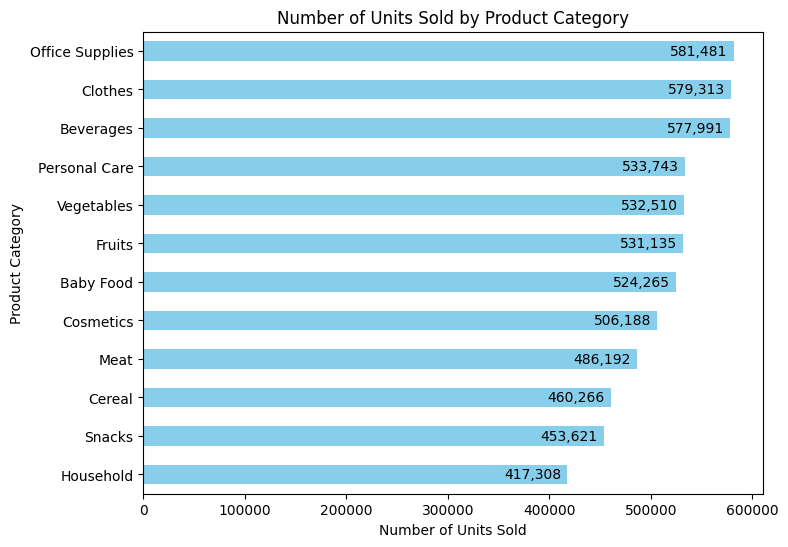

In [ ]:
# Grouping by Product Category and calculating units sold for each product
grouped_by_product_cat = data.groupby("Product Category")[["Units Sold"]].sum()
grouped_by_product_cat = grouped_by_product_cat.sort_values(by="Units Sold", ascending=True)

ax = grouped_by_product_cat.plot(kind="barh", color="skyblue", legend=False, figsize=(8,6))

ax.set_title("Number of Units Sold by Product Category")
ax.set_xlabel("Number of Units Sold")
ax.set_ylabel("Product Category")

for i, v in enumerate(grouped_by_product_cat["Units Sold"]):
    ax.text(v - max(grouped_by_product_cat["Units Sold"])*0.01, i, f"{int(round(v)):,}", color='black', va='center', ha='right')
plt.show()


Найбільше продано товарів у категорії **Канцелярія**

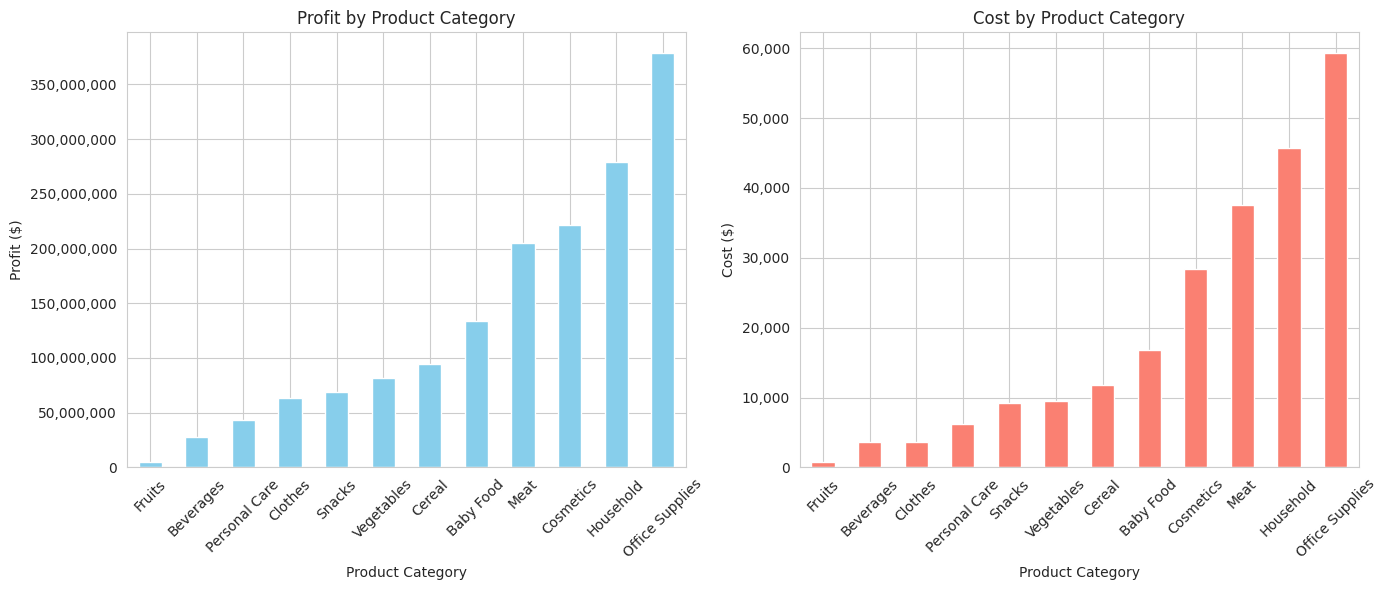

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


profit_by_cat = data.groupby("Product Category")[["Profit"]].sum().sort_values(by="Profit", ascending=True)
cost_by_cat = data.groupby("Product Category")[["Cost"]].sum().sort_values(by="Cost", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

profit_by_cat.plot(kind="bar", color="skyblue", legend=False, ax=axes[0])
axes[0].set_title("Profit by Product Category")
axes[0].set_xlabel("Product Category")
axes[0].set_ylabel("Profit ($)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x):,}'))

cost_by_cat.plot(kind="bar", color="salmon", legend=False, ax=axes[1])
axes[1].set_title("Cost by Product Category")
axes[1].set_xlabel("Product Category")
axes[1].set_ylabel("Cost ($)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()


Аналіз прибутку (profit) та витрат (cost) по категоріях показав, що “Канцелярія” має найвищі значення і там, і там.
Це означає, що саме ця категорія є наймасштабнішою у фінансовому плані, з високим обсягом продажів і відповідними витратами.  
Порядок категорій за прибутком і витратами співпадає, що свідчить про приблизно однакову рентабельність між категоріями. Тобто категорії з більшими витратами приносять пропорційно більший прибуток, а менш витратні – відповідно менший прибуток.

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

pie = go.Pie(
    labels=data['region'],
    values=data['Units Sold'],
    textinfo='percent+label',
    hole=0.0,
    marker=dict(colors=px.colors.qualitative.Pastel)
)

choropleth = px.choropleth(
    data,
    locations="Country",
    locationmode="country names",
    color="Units Sold",
    color_continuous_scale="Viridis"
)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'domain'}, {'type':'choropleth'}]],
    column_widths=[0.3, 0.7],
    subplot_titles=("Units Sold by Region", "Units Sold by Country")
)

fig.add_trace(pie, row=1, col=1)
for trace in choropleth.data:
    fig.add_trace(trace, row=1, col=2)

fig.show()



In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

pie = go.Pie(
    labels=data['region'],
    values=data['Profit'],
    textinfo='percent+label',
    hole=0.0,
    marker=dict(colors=px.colors.qualitative.Pastel)
)

choropleth = px.choropleth(
    data,
    locations="Country",
    locationmode="country names",
    color="Profit",
    color_continuous_scale="Viridis"
)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'domain'}, {'type':'choropleth'}]],
    column_widths=[0.3, 0.7],
    subplot_titles=("Profit by Region", "Profit by Country")
)

fig.add_trace(pie, row=1, col=1)
for trace in choropleth.data:
    fig.add_trace(trace, row=1, col=2)

fig.show()



In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

pie = go.Pie(
    labels=data['region'],
    values=data['Cost'],
    textinfo='percent+label',
    hole=0.0,
    marker=dict(colors=px.colors.qualitative.Pastel)
)

choropleth = px.choropleth(
    data,
    locations="Country",
    locationmode="country names",
    color="Cost",
    color_continuous_scale="Viridis"
)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'domain'}, {'type':'choropleth'}]],
    column_widths=[0.3, 0.7],
    subplot_titles=("Cost by Region", "Cost by Country")
)

fig.add_trace(pie, row=1, col=1)
for trace in choropleth.data:
    fig.add_trace(trace, row=1, col=2)

fig.show()

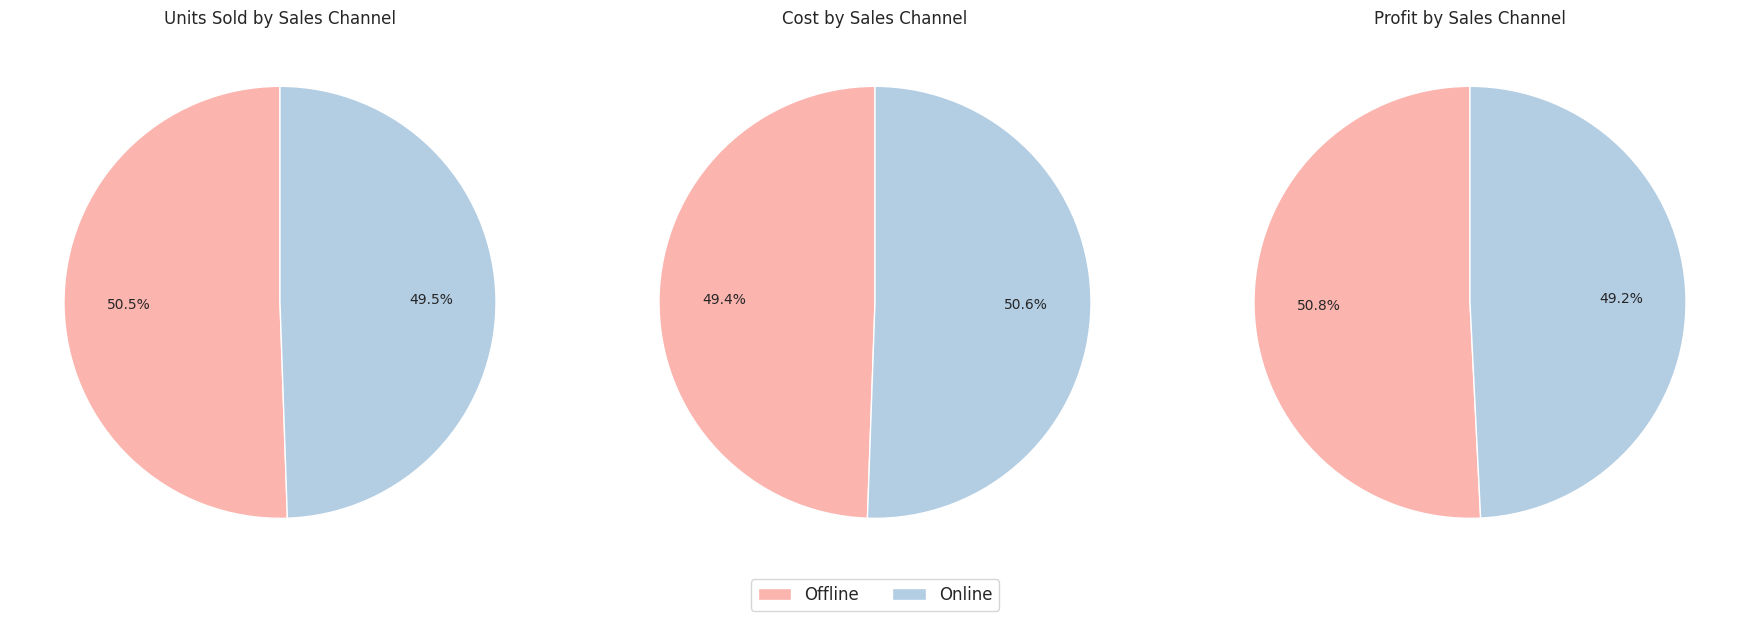

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Очищуємо назви каналів
data['Sales Channel'] = data['Sales Channel'].str.strip().str.title()

# Групування по Sales Channel
grouped_units = data.groupby('Sales Channel')['Units Sold'].sum()
grouped_cost = data.groupby('Sales Channel')['Cost'].sum()
grouped_profit = data.groupby('Sales Channel')['Profit'].sum()

fig, axes = plt.subplots(1, 3, figsize=(18,6))

colors = plt.cm.Pastel1.colors[:len(grouped_units)]

wedges0, texts0, autotexts0 = axes[0].pie(
    grouped_units,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.7
)
axes[0].set_title("Units Sold by Sales Channel")

wedges1, _, _ = axes[1].pie(
    grouped_cost,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.7
)
axes[1].set_title("Cost by Sales Channel")

wedges2, _, _ = axes[2].pie(
    grouped_profit,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.7
)
axes[2].set_title("Profit by Sales Channel")

fig.legend(
    wedges0,
    grouped_units.index,
    loc='lower center',
    ncol=len(grouped_units),
    fontsize=12
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


У розрізі всіх груп продажів показники онлайн та офлайн каналів збігаються, що свідчить про рівномірний розподіл продажів між каналами.

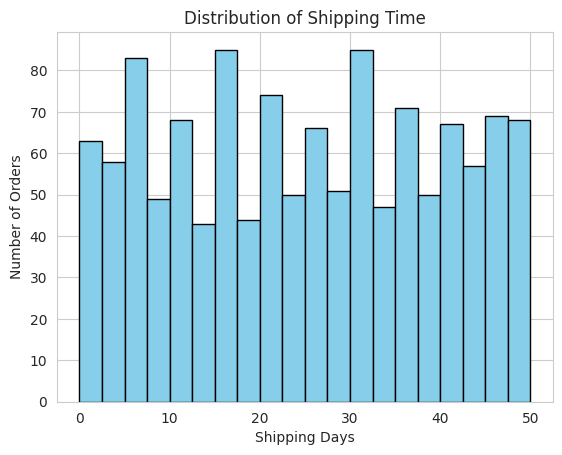

In [ ]:
data['Shipping Days'] = (data['Ship Date'] - data['Order Date']).dt.days

plt.hist(data['Shipping Days'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Shipping Days')
plt.ylabel('Number of Orders')
plt.title('Distribution of Shipping Time')
plt.show()

Гістограма показує, що більшість замовлень доставляються протягом 5-7, 15-18 та 30-32 днів. Є певна кількість замовлень з дуже коротким (0-2днів) або дуже довгим часом доставки(близько 50днів), що можна розглядати як аномальні значення. Загалом, час доставки концентрується навколо 28 днів.

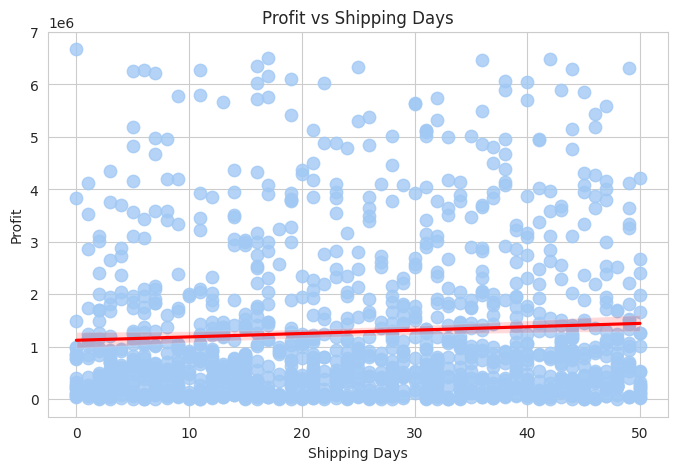

In [ ]:
agg_profit = data.groupby('Shipping Days')['Profit'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.regplot(x='Shipping Days', y='Profit', data=data, scatter_kws={'s':80}, line_kws={'color':'red'})
plt.xlabel('Shipping Days')
plt.ylabel('Profit')
plt.title('Profit vs Shipping Days')
plt.show()


Прибуток не залежить від тривалості доставки.

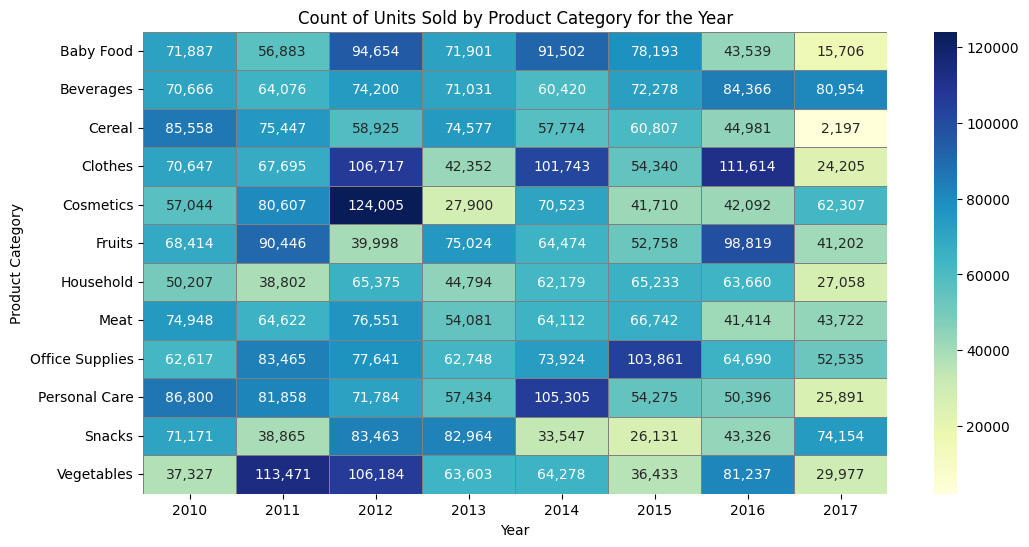

In [ ]:
data['Year'] = data['Order Date'].dt.to_period('Y').astype(str)
heatmap_data = data.groupby(['Product Category', 'Year'])['Units Sold'].sum().unstack(fill_value=0)
heatmap_data = heatmap_data.astype(int)
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt=',', cmap='YlGnBu', linewidths=0.5, linecolor='gray')
plt.title('Count of Units Sold by Product Category for the Year')
plt.ylabel('Product Category')
plt.xlabel('Year')
plt.yticks(rotation=0)
plt.show()

Лідери за кількістю проданих товарів з 2010 до 2017 року були наступні категорії:
*   2010 – Побутові товари,
*   2011 – Овочі,
*   2012 – Косметика,
*   2013 – Закуски,
*   2014 – Побутові товари,
*   2015 – Канцелярія,
*   2016 – Одяг,
*   2017 – Напої.

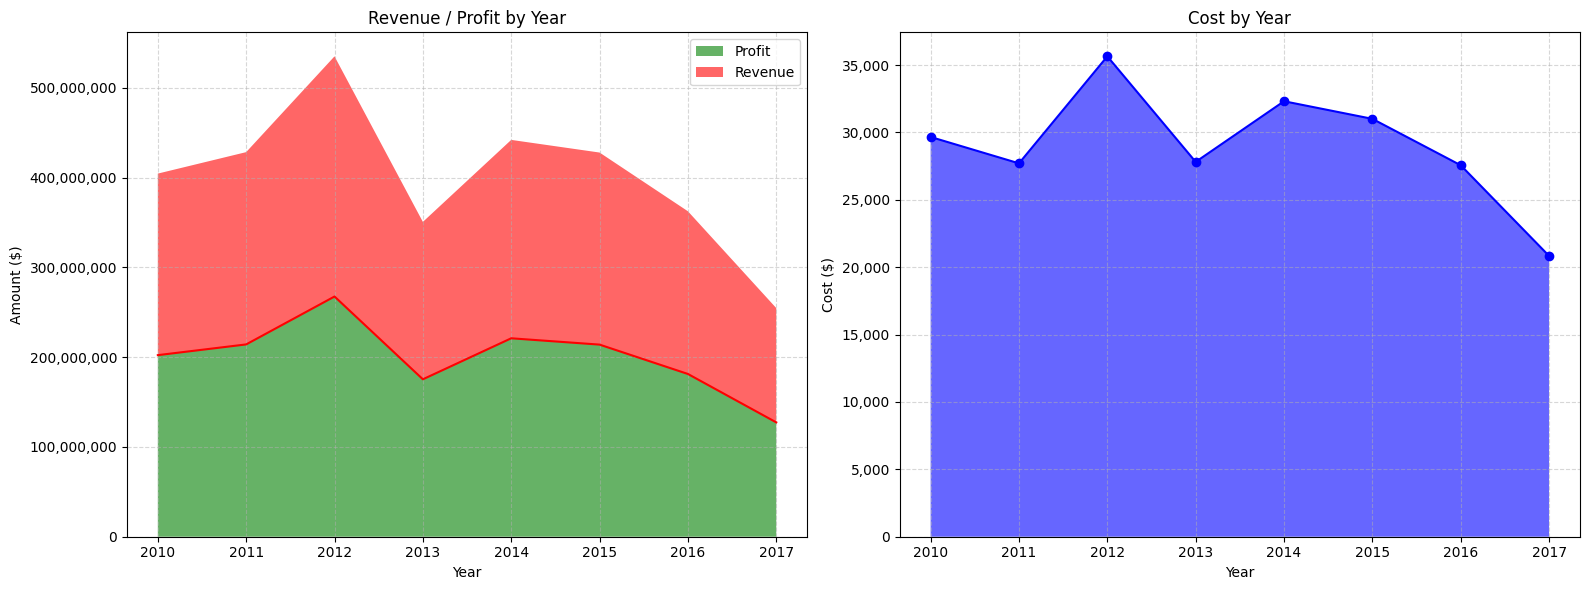

In [ ]:
import matplotlib.ticker as mtick

summary = data.groupby('Year')[['Profit', 'Revenue', 'Cost']].sum()

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# ---- Графік 1: Revenue / Profit (stacked area) ----
axes[0].stackplot(
    summary.index,
    summary['Profit'],
    summary['Revenue'],
    labels=['Profit', 'Revenue'],
    colors=['green', 'red'],
    alpha=0.6
)
axes[0].plot(summary.index, summary['Cost'] + summary['Profit'], color='red', linestyle='-')

axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
axes[0].set_title('Revenue / Profit by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Amount ($)')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks(summary.index)
axes[0].legend()

# ---- Графік 2: тільки Cost ----
axes[1].stackplot(
    summary.index,
    summary['Cost'],
    labels=['Cost'],
    colors=['blue'],
    alpha=0.6
)
axes[1].plot(summary.index, summary['Cost'], marker='o', color='blue', linestyle='-')
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
axes[1].set_title('Cost by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Cost ($)')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xticks(summary.index)

plt.tight_layout()
plt.show()


 Найприбутковішим роком був 2012, а найменш прибутковим – 2013.   У останні два роки спостерігається зменшення доходів

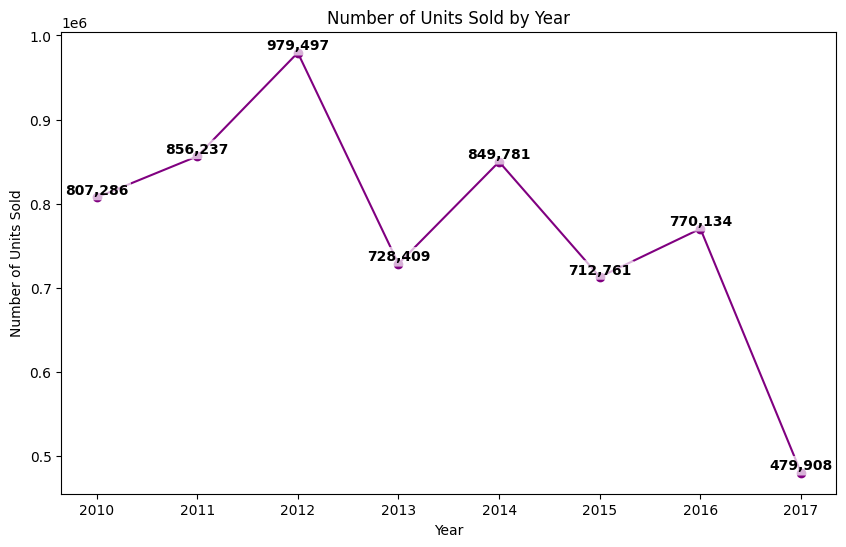

In [ ]:
price_summary = data.groupby('Year')['Units Sold'].sum()

plt.figure(figsize=(10,6))
plt.plot(price_summary.index, price_summary.values, marker='o', linestyle='-', color='purple')
plt.title('Number of Units Sold by Year')
plt.xlabel('Year')
plt.ylabel('Number of Units Sold')
plt.xticks(price_summary.index)
for x, y in zip(price_summary.index, price_summary.values):
        plt.text(
        x, y, f"{int(round(y)):,}",
        ha='center', va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')
    )
plt.show()


Аналіз даних показує, що кількість проданих товарів починаючи з 2012 року демонструє спадний тренд. Тимчасове зростання у 2014 році повернуло показники до рівня початкового періоду, проте після цього продажі знову знизилися. Ціни залишаються стабільними, тому для стимулювання продажів можна розглянути впровадження акцій, знижок або маркетингових кампаній, спрямованих на підвищення попиту.

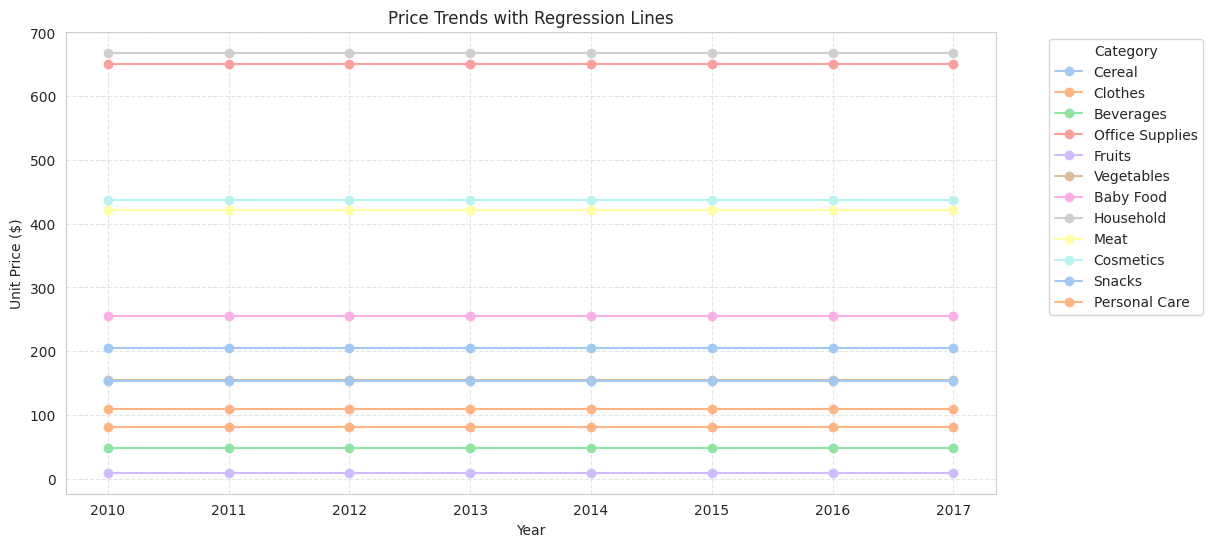

In [ ]:
from scipy.stats import linregress

plt.figure(figsize=(12,6))

for category in data['Product Category'].unique():
    df_cat = data[data['Product Category'] == category]

    data['Year'] = pd.to_numeric(data['Year'], errors='coerce')
    data = data.dropna(subset=['Year'])

    df_cat_year = df_cat.groupby('Year')['Unit Price'].mean().reset_index()
    df_cat_year = df_cat_year.sort_values('Year')

    x = df_cat_year['Year'].values
    y = df_cat_year['Unit Price'].values

    slope, intercept, _, _, _ = linregress(x, y)
    trend_line = intercept + slope * x

    plt.plot(x, y, marker='o', linestyle='-', label=category)

plt.title('Price Trends with Regression Lines')
plt.xlabel('Year')
plt.ylabel('Unit Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.show()



Середні ціни по всіх категоріях залишаються практично стабільними протягом усього аналізованого періоду. Трендів росту або падіння цін не спостерігається.

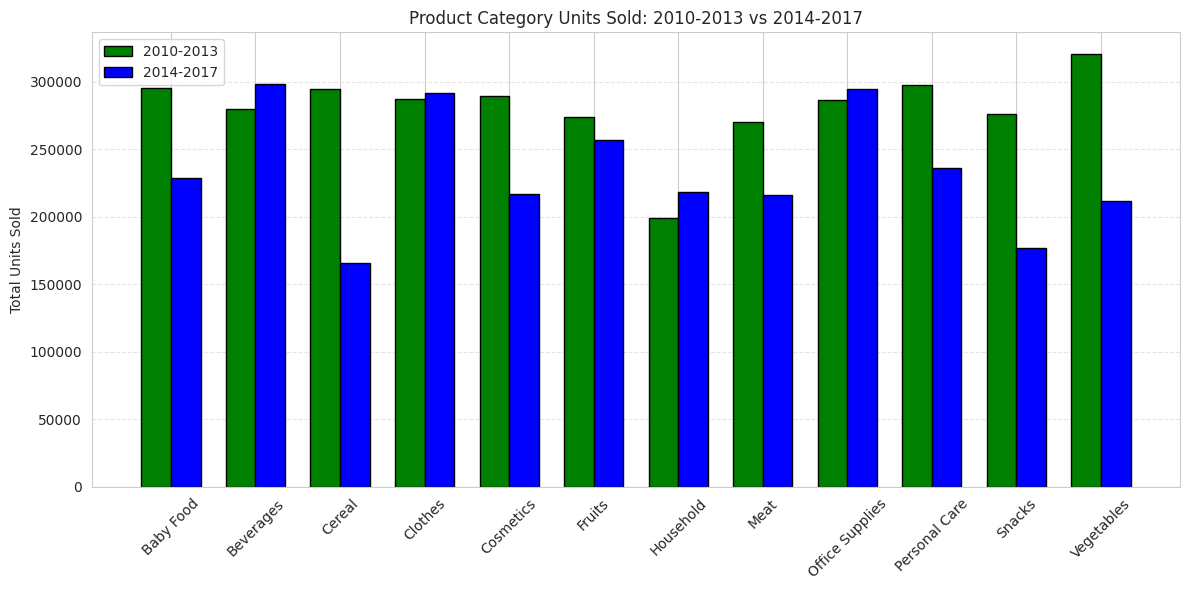

In [ ]:
# Units Sold 2010-2013 vs 2014-2017
profit_first4 = data[data['Year'].isin([2010, 2011, 2012, 2013])].groupby('Product Category')['Units Sold'].sum()
profit_last4 = data[data['Year'].isin([2014, 2015, 2016, 2017])].groupby('Product Category')['Units Sold'].sum()

all_categories = sorted(set(profit_first4.index).union(profit_last4.index))
values_first4 = [profit_first4.get(cat, 0) for cat in all_categories]
values_last4 = [profit_last4.get(cat, 0) for cat in all_categories]

x = np.arange(len(all_categories))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, values_first4, width, label='2010-2013', color='green', edgecolor='black')
plt.bar(x + width/2, values_last4, width, label='2014-2017', color='blue', edgecolor='black')

plt.xticks(x, all_categories, rotation=45)
plt.ylabel('Total Units Sold')
plt.title('Product Category Units Sold: 2010-2013 vs 2014-2017')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Аналіз двох часових періодів показує, що у 2010–2013 роках доходи зростали, з піковим значенням у 2012 році. У період 2014–2017 загальний рівень доходів досяг показників початкового періоду. Лише категорії Напої, Одяг, Товари для дому та Канцелярія демонструють невелике зростання у кількості продажів порівняно з попереднім періодом, тоді як решта категорій зазнала суттєвого зниження. Найбільше падіння спостерігається у категорії Крупи.

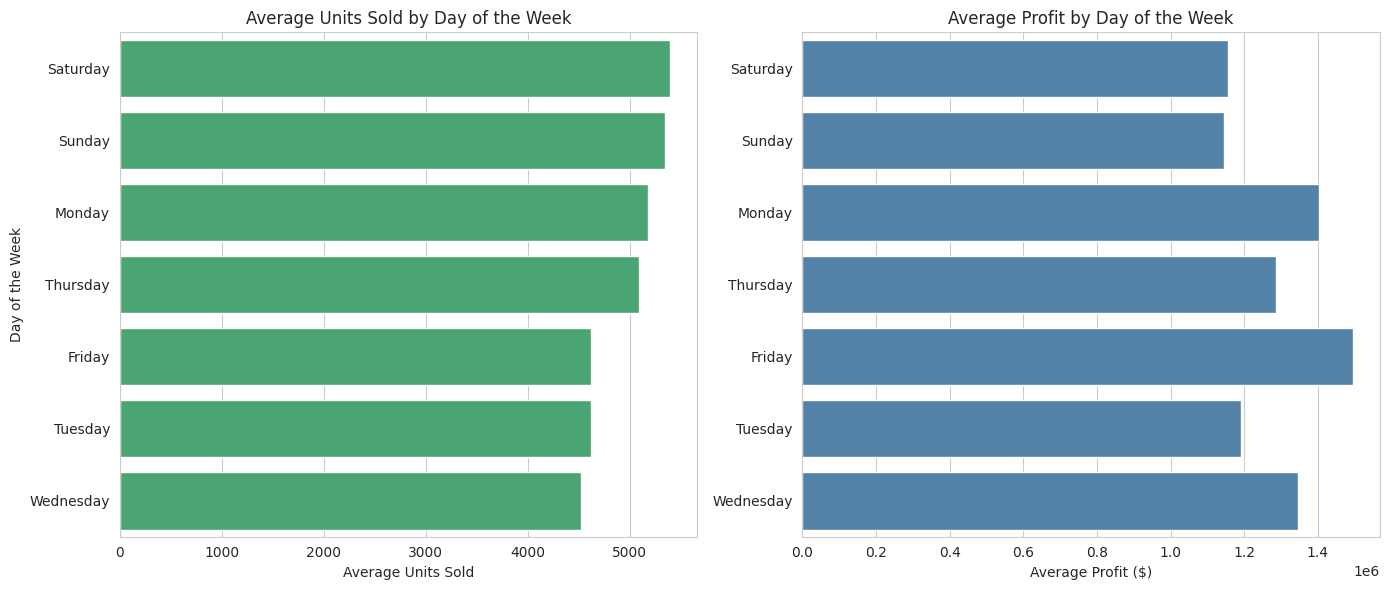

In [ ]:
avg_sales_units = (data.groupby(data['Order Date'].dt.day_name())['Units Sold'].median().reset_index())
avg_sales_units['Units Sold'] = avg_sales_units['Units Sold'].round().astype(int)
avg_sales_units = avg_sales_units.sort_values('Units Sold', ascending=False)

avg_sales_profit = (data.groupby(data['Order Date'].dt.day_name())['Profit'].mean().reset_index())
avg_sales_profit['Profit'] = avg_sales_profit['Profit'].round(2)
avg_sales_profit = avg_sales_profit.set_index('Order Date').loc[avg_sales_units['Order Date']].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.barplot(x='Units Sold', y='Order Date', data=avg_sales_units, color='mediumseagreen', orient='h', ax=axes[0])
axes[0].set_title('Average Units Sold by Day of the Week')
axes[0].set_xlabel('Average Units Sold')
axes[0].set_ylabel('Day of the Week')

sns.barplot(x='Profit', y='Order Date', data=avg_sales_profit, color='steelblue', orient='h', ax=axes[1])
axes[1].set_title('Average Profit by Day of the Week')
axes[1].set_xlabel('Average Profit ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()





Спостерігається невідповідність між днями з найбільшою кількістю замовлень та днями з найвищим прибутком. Зокрема, найбільша кількість замовлень припадає на неділю, тоді як максимальний дохід отримано у пʼятницю.

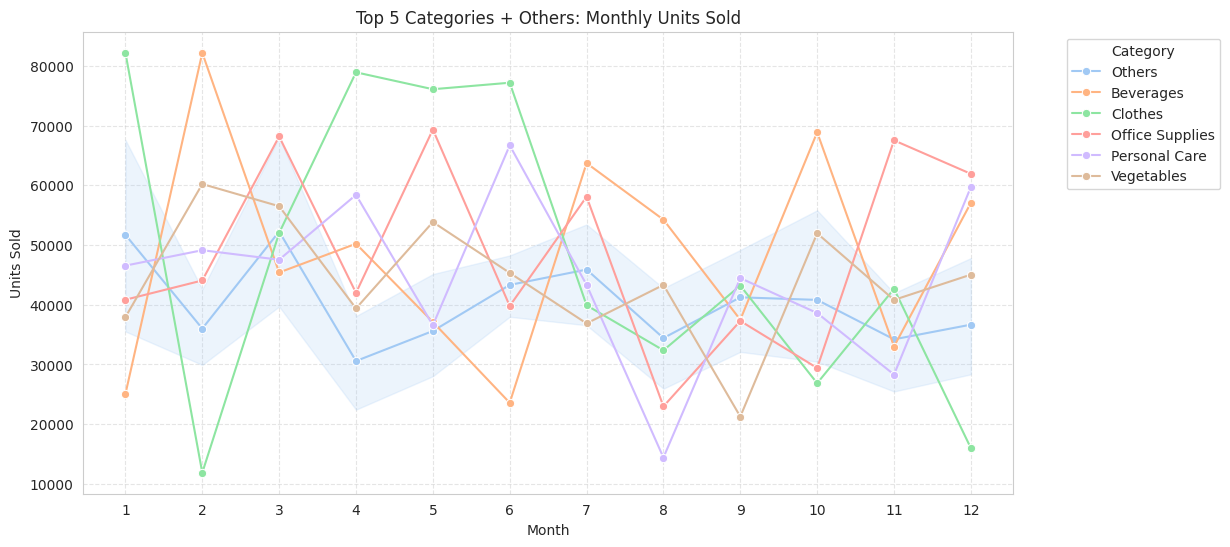

In [ ]:
data['Month'] = data['Order Date'].dt.month

monthly_sales = data.groupby(['Product Category', 'Month'])['Units Sold'].sum().reset_index()

# Визначаємо топ N категорій за сумарними продажами
N = 5
top_categories = monthly_sales.groupby('Product Category')['Units Sold'].sum().nlargest(N).index

monthly_sales['Category_plot'] = monthly_sales['Product Category'].where(
    monthly_sales['Product Category'].isin(top_categories), 'Others'
)

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Units Sold', hue='Category_plot', marker="o")
plt.title(f'Top {N} Categories + Others: Monthly Units Sold')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(range(1,13))
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


З графіку видно сезонні піки продажів по категоріях:  
**Одяг**— найбільше купують у січні, квітні та червні.  
**Напої**— пікові продажі у лютому.  
**Канцелярія**— популярна у березні, травні та листопаді.  
**Товари для догляду за собою** — основні продажі у червні.  
**Овочі** — найбільш активно купують у лютому та березні.

**Аналіз даних продажів за період 2010–2017 років показав наступні ключові тенденції:**

*Динаміка продажів по роках*:

У 2010–2013 роках спостерігалося зростання доходів, з піковим показником у 2012 році.

У період 2014–2017 доходи досягли рівня початкового періоду, але більшість категорій товарів зазнали зниження у кількості продажів.

Лише категорії Напої, Одяг, Товари для дому та Канцелярія показали невелике зростання, тоді як найбільше падіння спостерігається у категорії Крупи.

*Ціни та прибутковість:*

Ціни залишаються порівняно стабільними, середнє значення Unit Price і Unit Cost у деяких категоріях перевищує медіану, що свідчить про наявність високих значень, які впливають на середні показники.

Прибуток не залежить від кількості днів доставки; він формується переважно за рахунок структури продажів і категорій товарів.

*Сезонність та дні тижня:*

Продажі мають чітку сезонність:

Одяг — піки у січні, квітні та червні.

Напої — лютий.

Канцелярія — березень, травень, листопад.

Товари для догляду за собою — червень.

Овочі — лютий та березень.

*Невідповідність між кількістю замовлень та прибутком:* найбільша кількість замовлень припадає на четвер, тоді як максимальний дохід отримано у п’ятницю. Це вказує на те, що не всі замовлення приносять однаковий прибуток, і деякі дні є більш вигідними.

*Рекомендації:*

Для підвищення прибутковості доцільно оптимізувати асортимент, зосереджуючись на найбільш прибуткових категоріях у дні з високим трафіком замовлень.

Планувати маркетингові акції та знижки відповідно до сезонних піків для різних категорій.

Особливу увагу приділити категоріям з падінням продажів (наприклад, крупи) та розробити стратегії стимулювання попиту.